# Method Validation Notebook

This notebook validates that all Monte Carlo cross-section methods converge to consistent results.

The analysis covers three stages:
1. **Simulation Runner** — executes all method combinations and stores output
2. **Statistical Validation** — computes Z-score matrices to compare methods pairwise
3. **Performance Dashboard** — visualises speed, memory, and rejection metrics
4. **Neutron Balance Check** — verifies that absorption + leakage ≈ 1.0 per case
5. **Global Reaction Rates** — compares summed absorption / scatter totals across cases

---
## 0. Imports & Path Setup

In [3]:
import sys
import csv
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm

# Project-specific paths — update these to match your local setup
XS_LIB_PATH   = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron'
SRC_PATH       = '/home/paule/open_mc_projects/MC-1D_DT/structured_code'
VECTFIT_DIR    = Path(SRC_PATH) / 'src/vectfit_data'
OPENMC_FILE    = Path(SRC_PATH) / 'validation/method_validation/openmc_results_point.csv'

sys.path.extend([XS_LIB_PATH, SRC_PATH])

import geom_constructor
from src.geometry_classes import Geometry, Source, Material
import src.parallel as parallel
import src.export_print_csv as xp_sim

---
## 1. Simulation Configuration

In [4]:
# Method combinations to validate
xs_methods      = ['serpent', 'discrete', 'vectfit']
maj_mat_methods = ['maj_mat', 'simple']
access_methods  = ['fly', 'reconr']

# Simulation parameters
N_NEUTRONS = 20_000  # neutrons per batch
N_BATCHES  = 50      # independent batches

# Mono-energetic source at the slab centre, directed along +x
src = Source(
    neutron_nbr  = N_NEUTRONS,
    energy_range = [500, 150],
    energy_dist  = 'mono',
    position     = [0.0, 0.0, 0.0],
    direction    = [1.0, 0.0, 0.0],
)

---
## 2. Simulation Runner

Iterates over all method combinations. Each combination is skipped if complete
output already exists, or if a previous run logged an error.

In [ ]:
# Files that must be present for a run to be considered complete
REQUIRED_FILES = [
    'cross_batch_statistics_corrected.csv',
    'memory_poll.csv',
    'memory_summary.txt',
]
ERROR_FILES = ['error_log.txt']


def should_run(base: Path) -> bool:
    """Return True if the combination needs to be (re-)run."""
    if not base.exists():
        base.mkdir(parents=True, exist_ok=True)
        return True

    missing = [f for f in REQUIRED_FILES if not (base / f).exists()]
    errors  = [f for f in ERROR_FILES  if     (base / f).exists()]

    if missing:
        print(f'[INCOMPLETE] {base.name} — missing: {missing}')
        return True
    if errors:
        print(f'[ERROR LOG]  {base.name} — skipping.')
        return False
    return True  # complete and error-free → overwrite


for xs_method in xs_methods:
    # Only the 'discrete' method is run here; add other branches as needed
    if xs_method != 'discrete':
        continue

    for maj_mat_method in maj_mat_methods:
        for access_method in access_methods:

            output_dir = f'data/{xs_method}_{maj_mat_method}_{access_method}_{N_NEUTRONS}x{N_BATCHES}'
            base = Path(output_dir)

            if not should_run(base):
                print(f'[SKIP] {output_dir}')
                continue

            print(f'[RUN]  xs={xs_method}  maj={maj_mat_method}  access={access_method}')

            # --- Build geometry and run ---
            geom = batch_stats = None
            try:
                geom = geom_constructor.create_geometry_U8_slab(
                    maj_mat_method  = maj_mat_method,
                    maj_xs_method   = xs_method,
                    access_method   = access_method,
                    mode            = 'analysis',
                    xs_maj_file_dir = str(VECTFIT_DIR),
                )
                batch_stats = geom.run_batch_parallel(src, N_BATCHES, n_workers=20)

            except Exception as exc:
                print(f'  ERROR: {exc}')
                (base / 'error_log.txt').write_text(
                    f'xs={xs_method}, maj={maj_mat_method}, access={access_method}\n{exc}\n'
                )
                continue

            # --- Export results ---
            if batch_stats is not None and geom is not None:
                try:
                    xp_sim.export_cross_batch_stats(
                        batch_stats     = batch_stats,
                        geom            = geom,
                        print_to_console= False,
                        save_csv        = True,
                        output_dir      = output_dir,
                    )
                except Exception as exc:
                    print(f'  Cross-batch export failed: {exc}')

                try:
                    xp_sim.export_memory_stats(geom=geom, output_dir=output_dir)
                except Exception as exc:
                    print(f'  Memory export failed: {exc}')

---
## 3. Statistical Validation — Z-Score Matrix

For each pair of cases (A, B) and each tally bin *k*, the signed Z-score is:

$$Z = \frac{\mu_A - \mu_B}{\sqrt{\sigma_A^2 + \sigma_B^2}}$$

- **Off-diagonal cells**: heatmap of |Z| — bright colours indicate large discrepancies.
- **Diagonal cells**: histogram of all Z-scores for that row against every other column,
  overlaid with a standard normal N(0, 1) curve for reference.

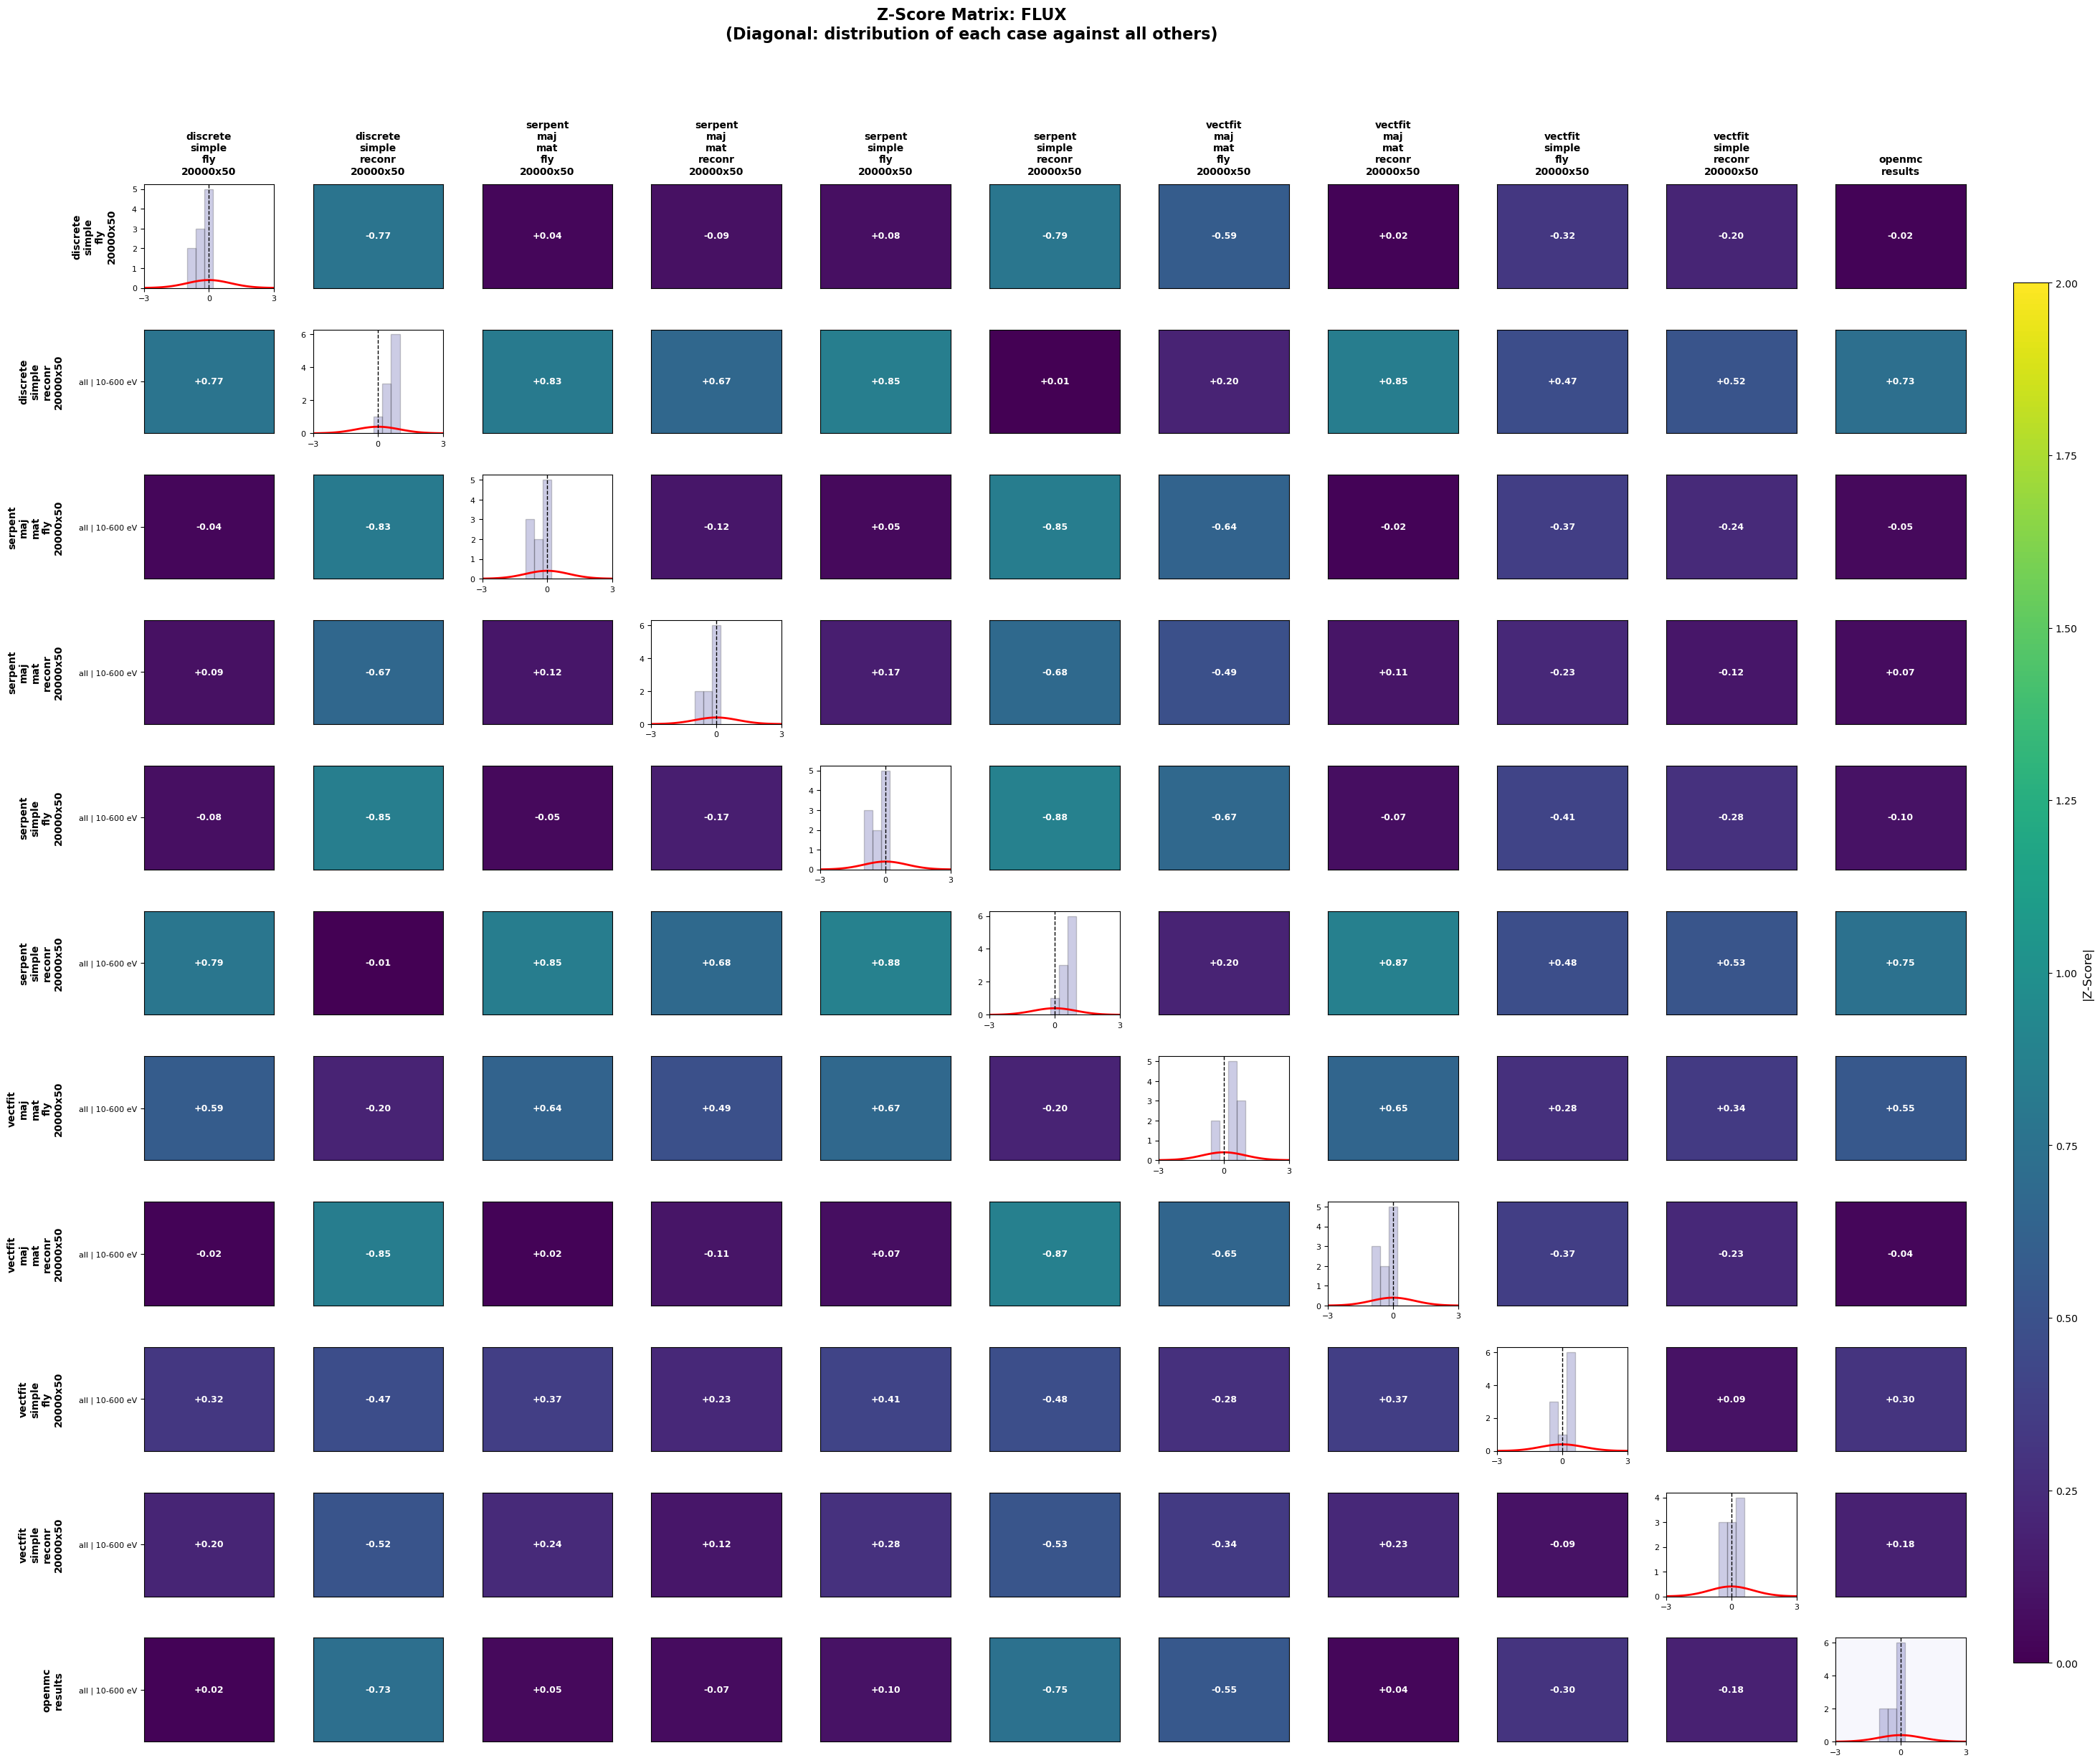

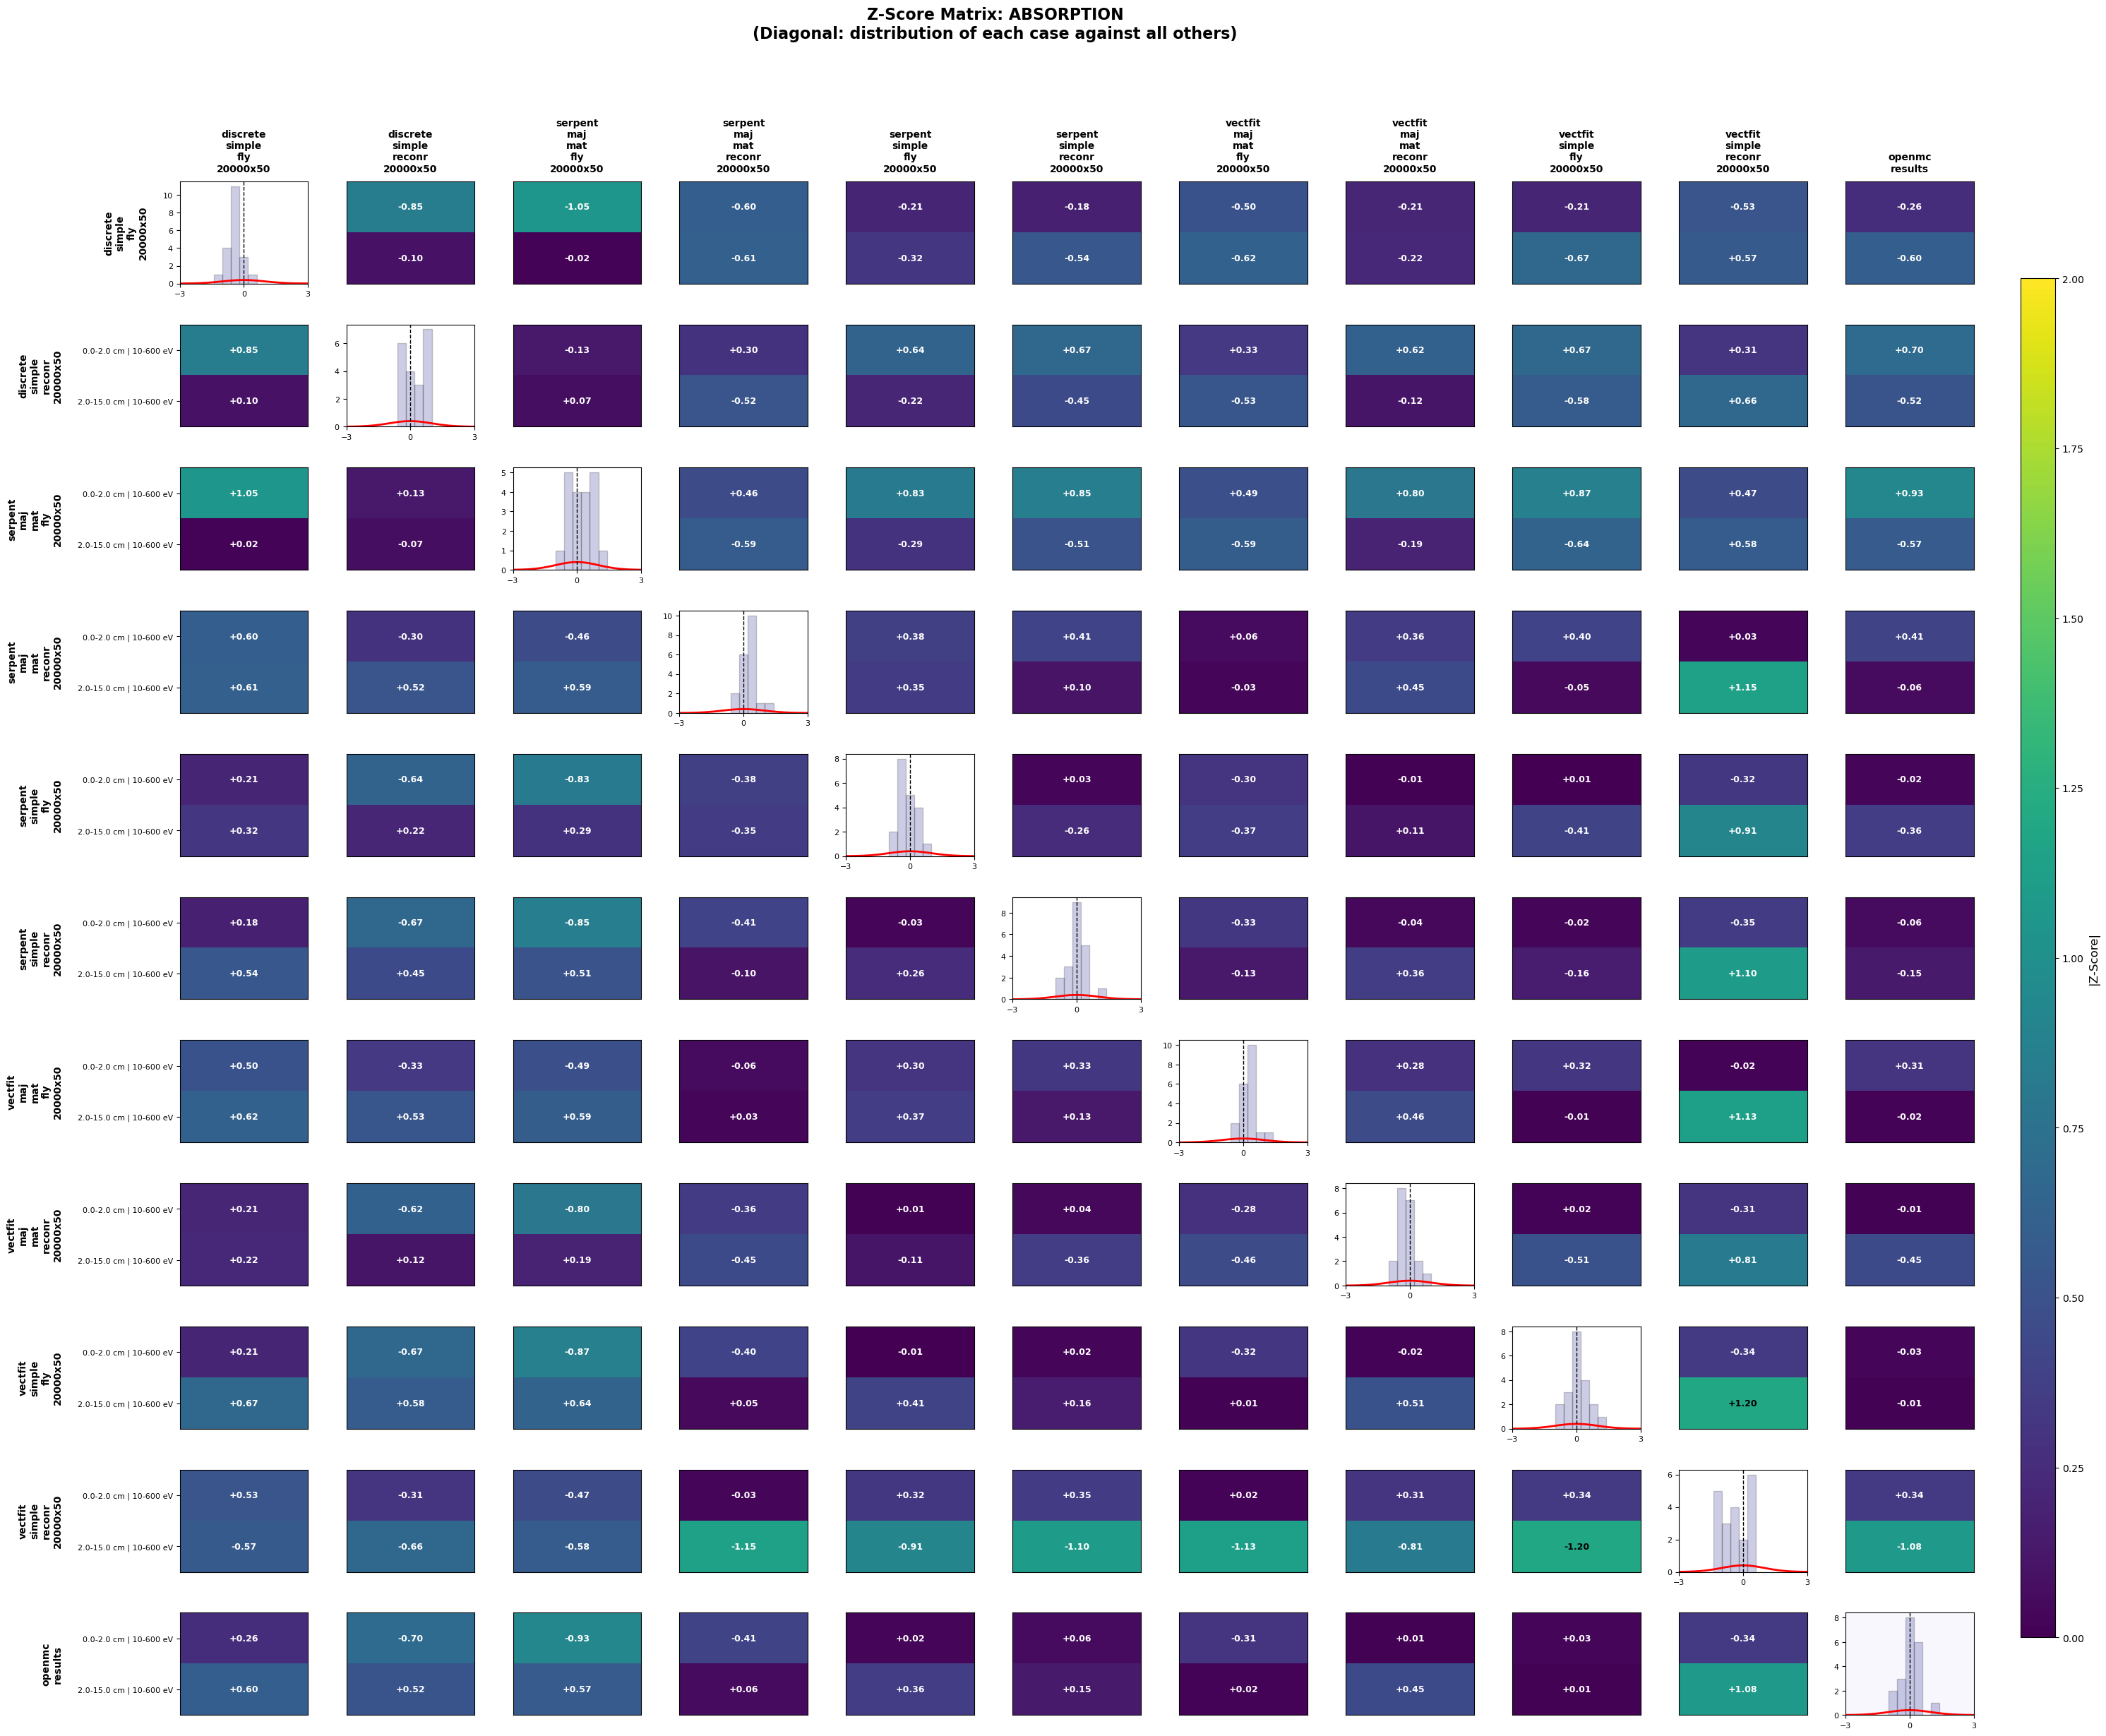

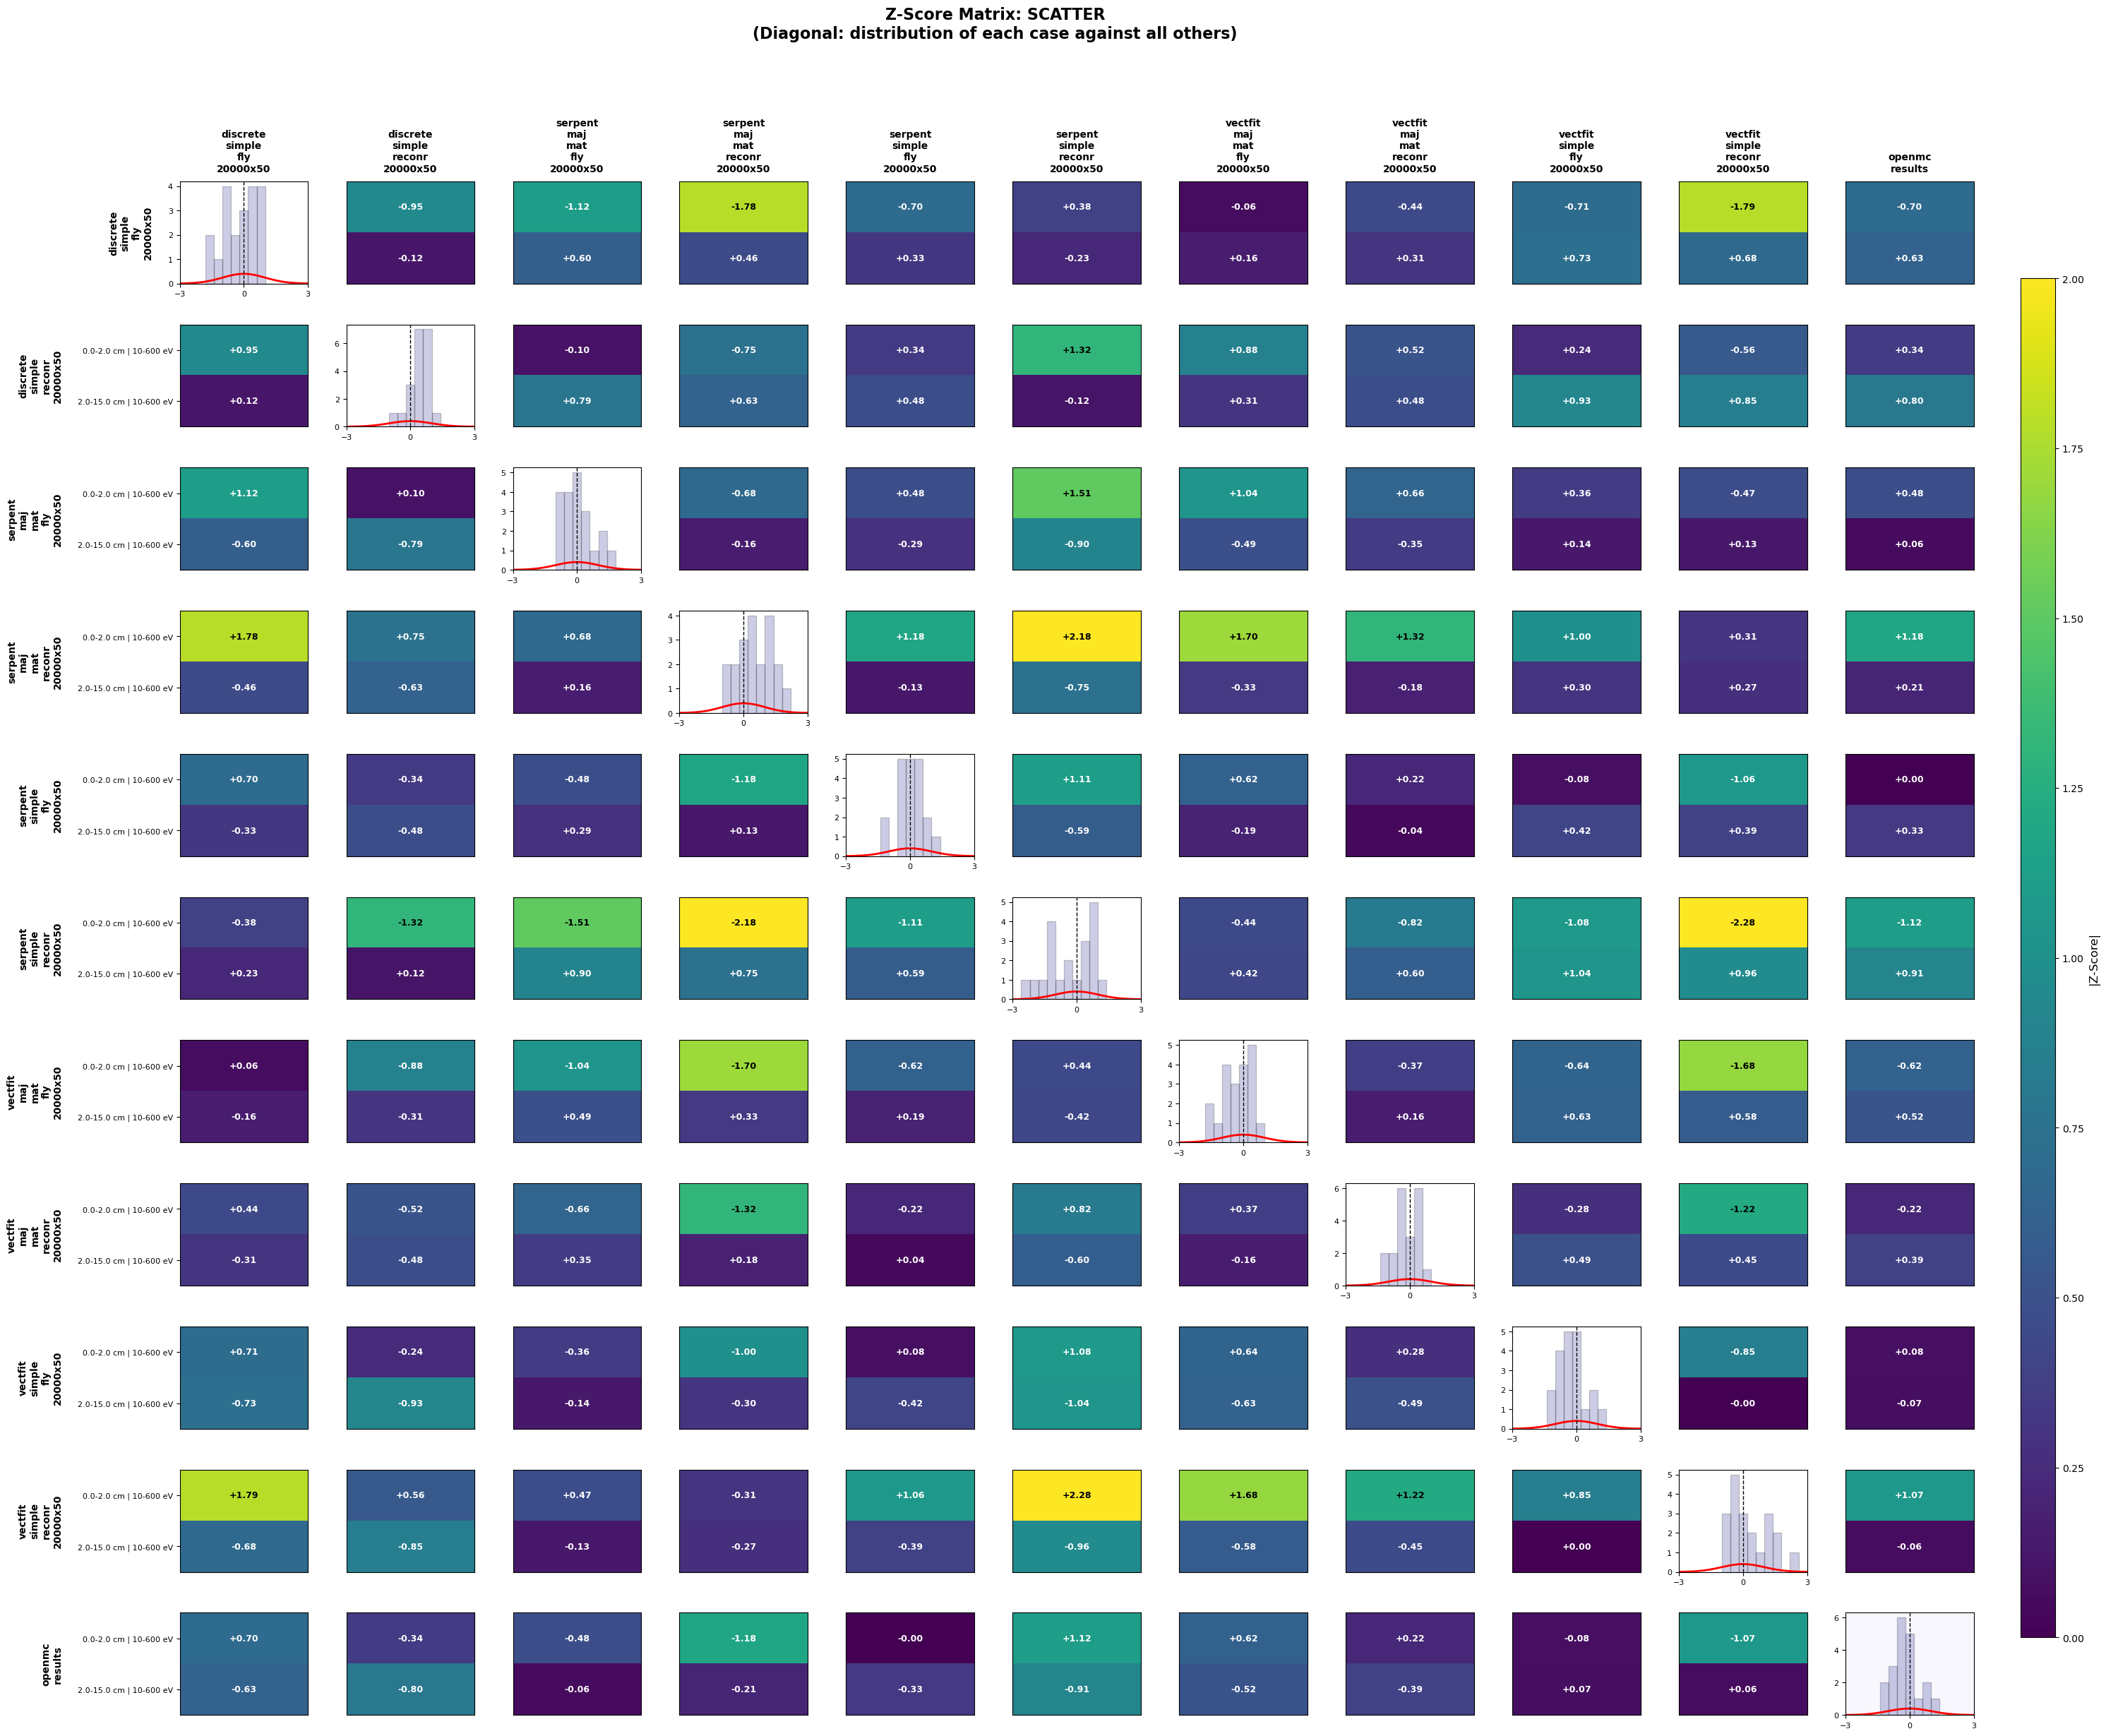

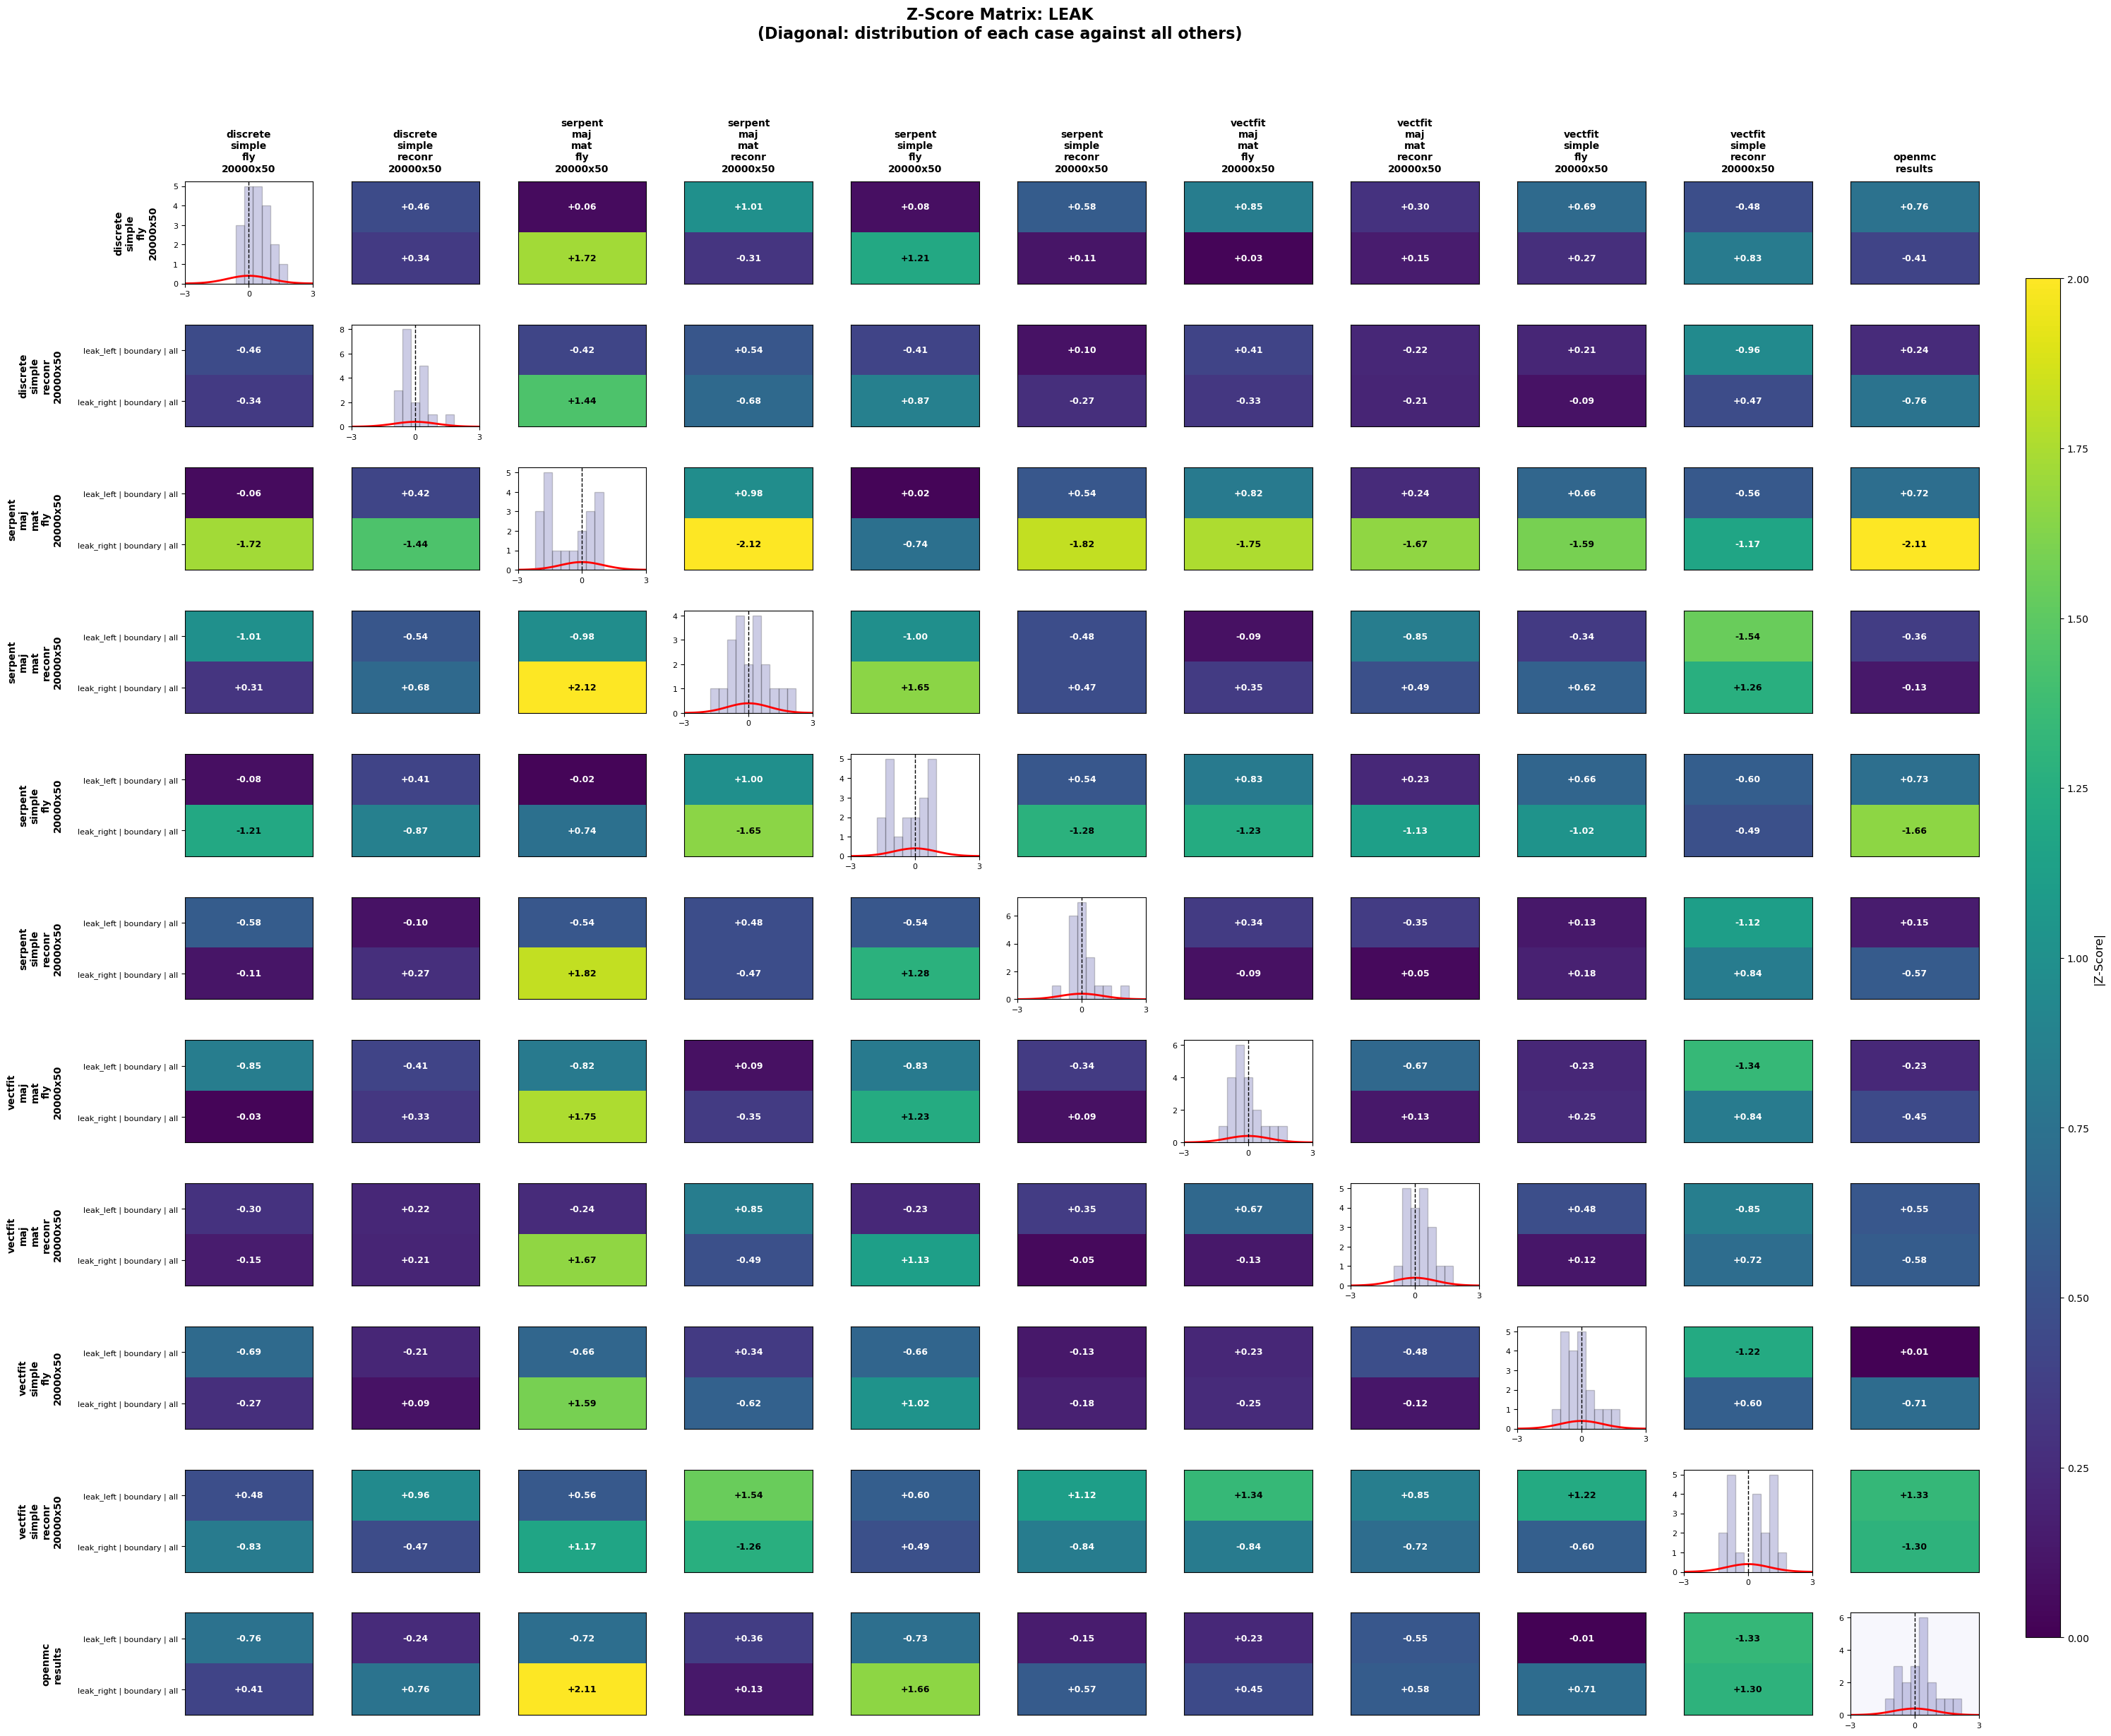

In [13]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

BASE_DIR = Path('/home/paule/open_mc_projects/MC-1D_DT/structured_code/validation/method_validation/data')

# Colour-scale ceiling for off-diagonal heatmaps
VMAX = 2.0

# Tally families to analyse separately
TARGET_FAMILIES = ['flux', 'absorption', 'scatter', 'leak']


# --- Helper: load and index a results CSV ---
def load_and_filter_data(csv_path: Path):
    """Load a cross-batch statistics CSV, drop performance rows, and index by tally_id."""
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    if 'region' in df.columns:
        df = df[df['region'] != 'performance'].copy()
    df['tally_id'] = df['tally'] + ' | ' + df['region'] + ' | ' + df['energy_group']
    df['mean']     = df['mean'].abs()  # treat backward currents as positive
    return df.set_index('tally_id')[['mean', 'std']]


# --- Load all valid simulation cases ---
valid_cases: dict[str, pd.DataFrame] = {}

if BASE_DIR.exists():
    for d in BASE_DIR.iterdir():
        if d.is_dir() and not (d / 'error_log.txt').exists():
            df = load_and_filter_data(d / 'cross_batch_statistics_corrected.csv')
            if df is not None:
                valid_cases[d.name] = df

if OPENMC_FILE.exists():
    df = load_and_filter_data(OPENMC_FILE)
    if df is not None:
        valid_cases['openmc_results'] = df

if not valid_cases:
    raise ValueError('No valid data found — run the simulation cells first.')

# Sort alphabetically; keep OpenMC last as the reference
_names = [k for k in valid_cases if k != 'openmc_results']
case_names = sorted(_names) + (['openmc_results'] if 'openmc_results' in valid_cases else [])
n_cases    = len(case_names)

# Active tallies: at least one case has a nonzero mean
all_tally_ids = set().union(*[df.index for df in valid_cases.values()])
active_tallies = [
    t for t in all_tally_ids
    if any(t in df.index and df.loc[t, 'mean'] > 0.0 for df in valid_cases.values())
]

def get_family(tally_id: str) -> str:
    base = tally_id.split(' | ')[0]
    return 'leak' if 'leak' in base else base


# --- Plot Z-score matrix per tally family ---
for family in TARGET_FAMILIES:
    family_tallies = sorted([t for t in active_tallies if get_family(t) == family])
    n_tallies = len(family_tallies)
    if n_tallies == 0:
        continue

    # Build Z-score tensor: shape (n_cases, n_cases, n_tallies)
    z_matrix = np.zeros((n_cases, n_cases, n_tallies))

    for i, name_a in enumerate(case_names):
        df_a = valid_cases[name_a]
        for j, name_b in enumerate(case_names):
            if i == j:
                continue
            df_b = valid_cases[name_b]
            for k, tid in enumerate(family_tallies):
                if tid in df_a.index and tid in df_b.index:
                    mu_a, s_a = df_a.loc[tid, 'mean'], df_a.loc[tid, 'std']
                    mu_b, s_b = df_b.loc[tid, 'mean'], df_b.loc[tid, 'std']
                    var_sum   = s_a**2 + s_b**2
                    z = 0.0 if var_sum == 0 and mu_a == mu_b else (
                        np.nan if var_sum == 0 else (mu_a - mu_b) / np.sqrt(var_sum)
                    )
                    z_matrix[i, j, k] = 0.0 if not np.isfinite(z) else z

    # --- Visualisation ---
    fig, axes = plt.subplots(
        n_cases, n_cases,
        figsize=(max(16, 3 * n_cases), max(14, 2.5 * n_cases))
    )
    if n_cases == 2:
        axes = np.array(axes).reshape(2, 2)

    for i in range(n_cases):
        for j in range(n_cases):
            ax = axes[i, j]

            if i == 0:
                ax.set_title(case_names[j].replace('_', '\n'), fontsize=10, fontweight='bold', pad=10)
            if j == 0:
                ax.set_ylabel(case_names[i].replace('_', '\n'), fontsize=10, fontweight='bold', labelpad=15)

            if i == j:
                # Diagonal: histogram of Z-scores for row i vs all other columns
                all_z = [z for m in range(n_cases) if m != i for z in z_matrix[i, m, :]]
                ax.hist(all_z, bins=15, range=(-3, 3), color='navy', alpha=0.2, edgecolor='black')
                x = np.linspace(-3, 3, 100)
                ax.plot(x, norm.pdf(x, 0, 1), 'r-', lw=2, label='N(0,1)')
                ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
                ax.set_xlim(-3, 3)
                ax.set_xticks([-3, 0, 3])
                ax.tick_params(axis='both', which='both', labelsize=8)
                if case_names[i] == 'openmc_results':
                    ax.patch.set_facecolor('lavender')
                    ax.patch.set_alpha(0.3)
                continue

            # Off-diagonal: heatmap coloured by |Z|, annotated with signed Z
            z_vals = z_matrix[i, j, :].reshape(-1, 1)
            im = ax.imshow(np.abs(z_vals), aspect='auto', cmap='viridis', vmin=0, vmax=VMAX)
            for k, z in enumerate(z_vals.flatten()):
                txt_color = 'black' if np.abs(z) > VMAX * 0.6 else 'white'
                ax.text(0, k, '0' if z == 0 else f'{z:+.2f}',
                        ha='center', va='center', color=txt_color, fontsize=9, fontweight='bold')
            ax.set_xticks([])
            if j == 0:
                clean_labels = [t.replace(f'{family} | ', '') for t in family_tallies]
                ax.set_yticks(range(n_tallies))
                ax.set_yticklabels(clean_labels, fontsize=8)
            else:
                ax.set_yticks([])

    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax).set_label('|Z-Score|', fontsize=12)
    plt.suptitle(
        f'Z-Score Matrix: {family.upper()}\n'
        f'(Diagonal: distribution of each case against all others)',
        fontsize=16, fontweight='bold', y=0.99
    )
    plt.subplots_adjust(left=0.15, top=0.9, right=0.92, wspace=0.3, hspace=0.4)
    plt.show()

---
## 4. Performance Dashboard

Horizontal bar charts for:
- Wrong majorant fraction and mean error (log scale, with ±1σ error bars)
- Computational speed (neutrons per second)
- Rejection fraction
- Peak and total memory growth

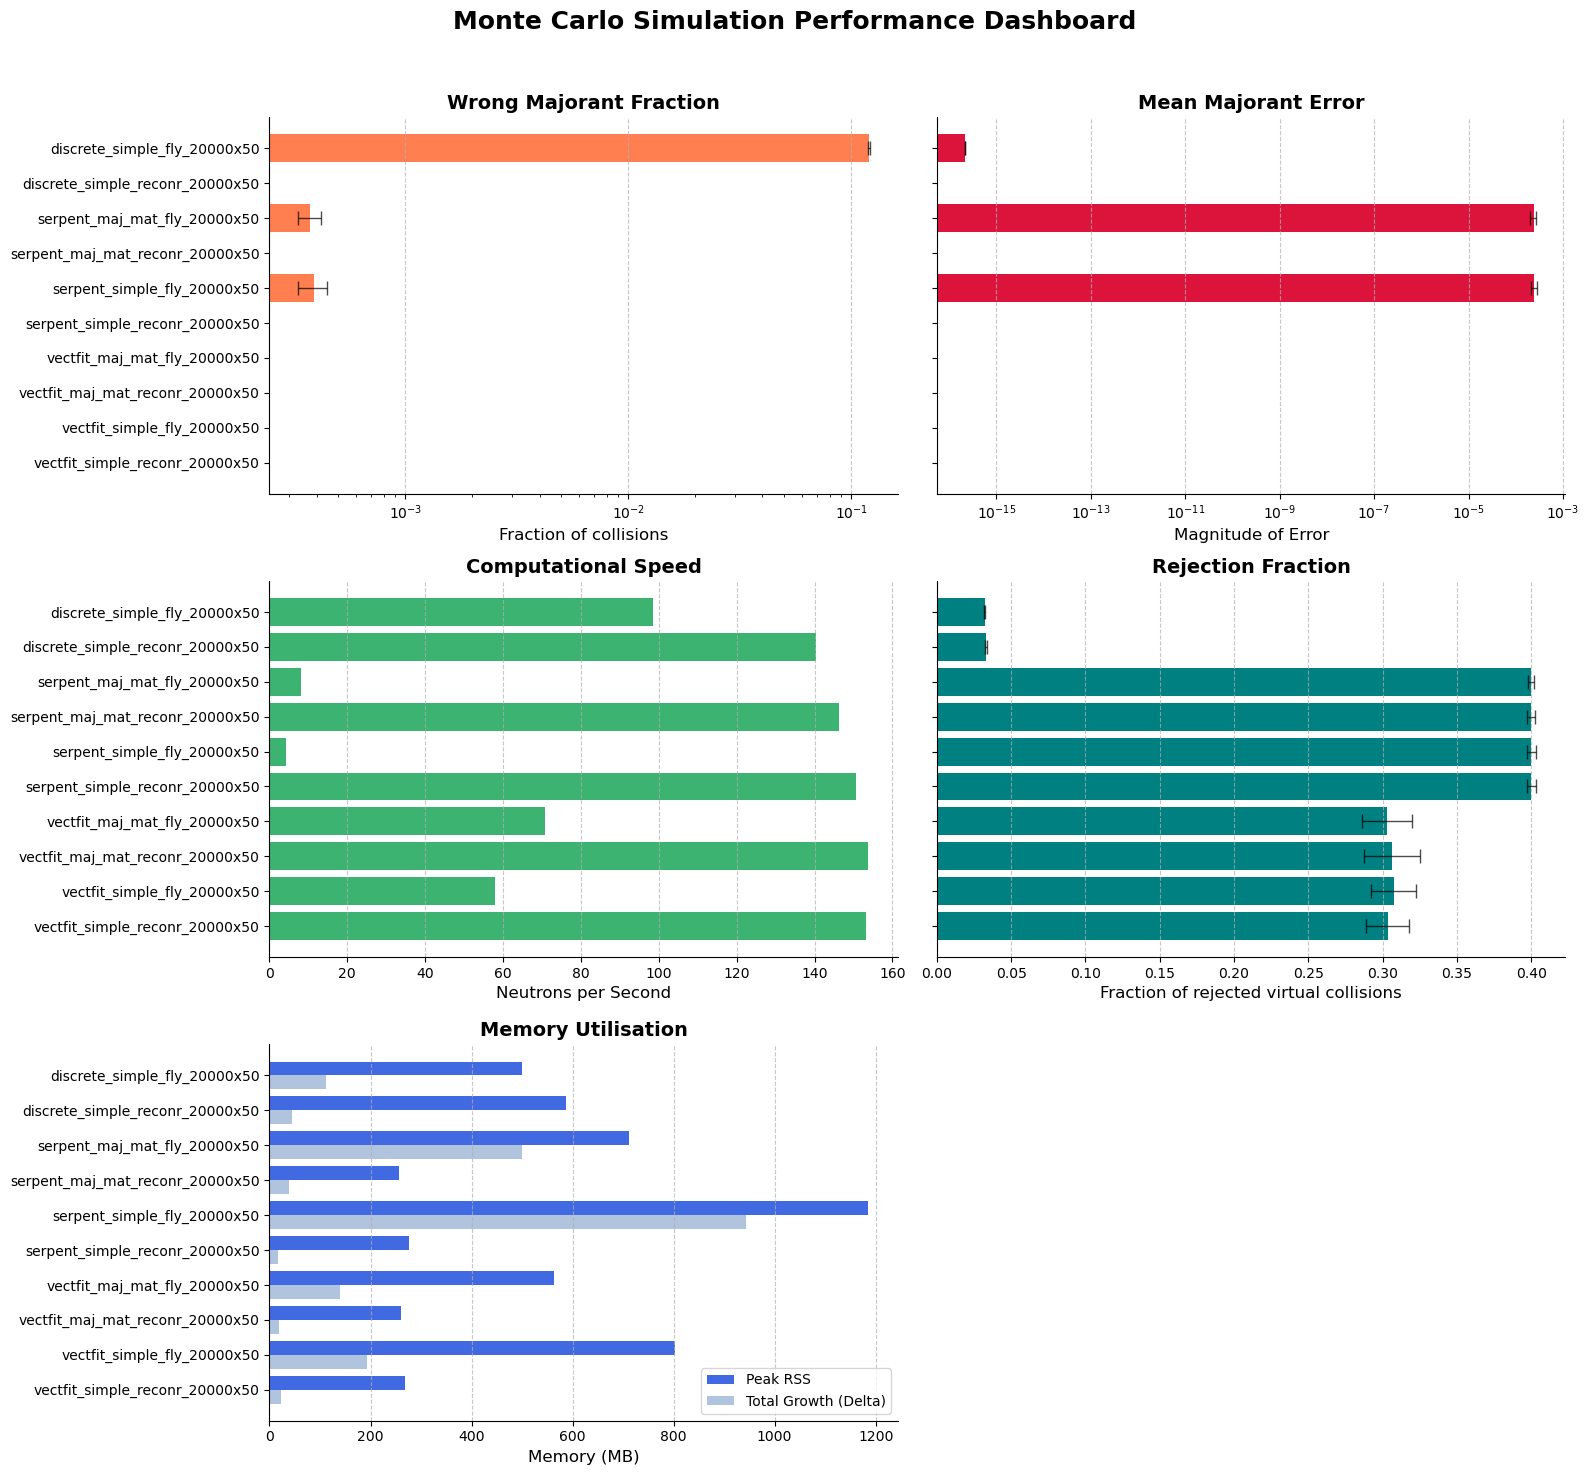

In [14]:
# --- Data extraction ---
perf_case_names: list[str] = []
metrics: dict[str, list] = {
    'wrong_maj_frac':     [],
    'wrong_maj_frac_std': [],
    'wrong_maj_err':      [],
    'wrong_maj_err_std':  [],
    'nps':                [],
    'rej_frac':           [],
    'rej_frac_std':       [],
    'peak_mem':           [],
    'delta_mem':          [],
}

PERF_KEYS = {
    'wrong_maj_frac':     'wrong_majorant_fraction',
    'wrong_maj_err':      'wrong_majorant_mean_error',
    'nps':                'neutrons_per_second',
    'rej_frac':           'rejection_fraction',
}

if BASE_DIR.exists():
    for d in sorted(BASE_DIR.iterdir()):
        if not d.is_dir() or (d / 'error_log.txt').exists() or d.name == 'openmc_results':
            continue

        csv_file = d / 'cross_batch_statistics_corrected.csv'
        if not csv_file.exists():
            continue

        df      = pd.read_csv(csv_file)
        perf_df = df[df['region'] == 'performance'].set_index('tally')

        for short_key, row_key in PERF_KEYS.items():
            metrics[short_key].append(
                perf_df.loc[row_key, 'mean'] if row_key in perf_df.index else 0
            )
            if short_key != 'nps':  # nps has no std column to extract
                metrics[f'{short_key}_std'].append(
                    perf_df.loc[row_key, 'std'] if row_key in perf_df.index else 0
                )

        # Memory stats from the summary text file
        peak = delta = 0.0
        mem_file = d / 'memory_summary.txt'
        if mem_file.exists():
            content     = mem_file.read_text()
            m_peak      = re.search(r'Peak RSS \(continuous\)\s*:\s*([\d\.e+\-]+)', content)
            m_growth    = re.search(r'Total growth\s*:\s*\+?([\d\.e+\-]+)', content)
            if m_peak:   peak  = float(m_peak.group(1))
            if m_growth: delta = float(m_growth.group(1))
        metrics['peak_mem'].append(peak)
        metrics['delta_mem'].append(delta)

        perf_case_names.append(d.name)

if not perf_case_names:
    raise ValueError('No valid performance data found.')


# --- Visualisation ---
def style_ax(ax, title: str, xlabel: str) -> None:
    """Apply consistent styling to a horizontal bar chart."""
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()  # alphabetical top-to-bottom


y_pos = np.arange(len(perf_case_names))
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Monte Carlo Simulation Performance Dashboard', fontsize=18, fontweight='bold', y=0.98)

err_kw = {'linewidth': 1, 'alpha': 0.7}

# Row 0: Majorant quality
ax = axes[0, 0]
ax.barh(y_pos, metrics['wrong_maj_frac'], xerr=metrics['wrong_maj_frac_std'],
        capsize=5, error_kw=err_kw, color='coral')
ax.set_yticks(y_pos); ax.set_yticklabels(perf_case_names, fontsize=10)
ax.set_xscale('log')
style_ax(ax, 'Wrong Majorant Fraction', 'Fraction of collisions')

ax = axes[0, 1]
ax.barh(y_pos, metrics['wrong_maj_err'], xerr=metrics['wrong_maj_err_std'],
        capsize=5, error_kw=err_kw, color='crimson')
ax.set_yticks(y_pos); ax.set_yticklabels([])
ax.set_xscale('log')
style_ax(ax, 'Mean Majorant Error', 'Magnitude of Error')

# Row 1: Efficiency
ax = axes[1, 0]
ax.barh(y_pos, metrics['nps'], color='mediumseagreen')
ax.set_yticks(y_pos); ax.set_yticklabels(perf_case_names, fontsize=10)
style_ax(ax, 'Computational Speed', 'Neutrons per Second')

ax = axes[1, 1]
ax.barh(y_pos, metrics['rej_frac'], xerr=metrics['rej_frac_std'],
        capsize=5, error_kw=err_kw, color='teal')
ax.set_yticks(y_pos); ax.set_yticklabels([])
style_ax(ax, 'Rejection Fraction', 'Fraction of rejected virtual collisions')

# Row 2: Memory (grouped)
height = 0.4
ax = axes[2, 0]
ax.barh(y_pos - height / 2, metrics['peak_mem'],  height=height, label='Peak RSS',            color='royalblue')
ax.barh(y_pos + height / 2, metrics['delta_mem'], height=height, label='Total Growth (Delta)', color='lightsteelblue')
ax.set_yticks(y_pos); ax.set_yticklabels(perf_case_names, fontsize=10)
style_ax(ax, 'Memory Utilisation', 'Memory (MB)')
ax.legend(loc='lower right')

axes[2, 1].axis('off')  # unused subplot

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## 5. Neutron Balance Check

For a fixed-source problem the total probability must satisfy:

$$P_{\text{abs}} + P_{\text{leak}} = 1.0$$

Significant deviations flag energy-group bookkeeping errors or missing tally bins.

In [15]:
# Re-use load_and_filter_data from Section 3 (run that cell first)

balance_rows = []
for case_name, df in valid_cases.items():
    total_abs  = df[df.index.str.startswith('absorption')]['mean'].sum()
    total_leak = df[df.index.str.contains('leak')]['mean'].sum()
    total      = total_abs + total_leak
    balance_rows.append({
        'Case Name':          case_name,
        'Absorption':         total_abs,
        'Leakage':            total_leak,
        'Total (Abs + Leak)': total,
        'Difference from 1.0': abs(1.0 - total),
    })

balance_df  = pd.DataFrame(balance_rows)
openmc_mask = balance_df['Case Name'] == 'openmc_results'
sorted_df   = pd.concat([
    balance_df[~openmc_mask].sort_values('Case Name'),
    balance_df[openmc_mask],
]).reset_index(drop=True)

fmt = {
    'Absorption':         '{:.5f}'.format,
    'Leakage':            '{:.5f}'.format,
    'Total (Abs + Leak)': '{:.5f}'.format,
    'Difference from 1.0':'{:.5e}'.format,
}

print('=' * 105)
print(f'{"Neutron Balance Check (Target = 1.0)":^105}')
print('=' * 105)
print(sorted_df.to_string(index=False, formatters=fmt, justify='left'))
print('-' * 105)

                                  Neutron Balance Check (Target = 1.0)                                   
Case Name                       Absorption Leakage Total (Abs + Leak) Difference from 1.0
   discrete_simple_fly_20000x50 0.47688    0.52312 1.00000            0.00000e+00        
discrete_simple_reconr_20000x50 0.47732    0.52268 1.00000            2.22045e-16        
   serpent_maj_mat_fly_20000x50 0.47732    0.52268 1.00000            2.22045e-16        
serpent_maj_mat_reconr_20000x50 0.47758    0.52242 1.00000            0.00000e+00        
    serpent_simple_fly_20000x50 0.47719    0.52281 1.00000            0.00000e+00        
 serpent_simple_reconr_20000x50 0.47734    0.52266 1.00000            2.22045e-16        
   vectfit_maj_mat_fly_20000x50 0.47758    0.52242 1.00000            2.22045e-16        
vectfit_maj_mat_reconr_20000x50 0.47712    0.52288 1.00000            0.00000e+00        
    vectfit_simple_fly_20000x50 0.47746    0.52254 1.00000            2.22045e-16   

---
## 6. Global Reaction Rate Comparison

Summed absorption and scatter rates across all bins, plotted as vertical lines
with ±2σ error bars. The OpenMC reference is shown as a dashed line with a shaded
±2σ band.

CASE NAME                           | ABSORPTION   | SCATTERING   | TOTAL RX    
-------------------------------------------------------------------------------------
discrete_simple_fly_20000x50        | 0.47688      | 7.18312      | 7.66000
discrete_simple_reconr_20000x50     | 0.47732      | 7.18821      | 7.66553
serpent_maj_mat_fly_20000x50        | 0.47732      | 7.18042      | 7.65774
serpent_maj_mat_reconr_20000x50     | 0.47758      | 7.18489      | 7.66247
serpent_simple_fly_20000x50         | 0.47719      | 7.18176      | 7.65895
serpent_simple_reconr_20000x50      | 0.47734      | 7.18433      | 7.66167
vectfit_maj_mat_fly_20000x50        | 0.47758      | 7.18156      | 7.65914
vectfit_maj_mat_reconr_20000x50     | 0.47712      | 7.18138      | 7.65850
vectfit_simple_fly_20000x50         | 0.47746      | 7.17750      | 7.65496
vectfit_simple_reconr_20000x50      | 0.47666      | 7.18064      | 7.65731
openmc_results                      | 0.47748      | 7.17800      | 7.655

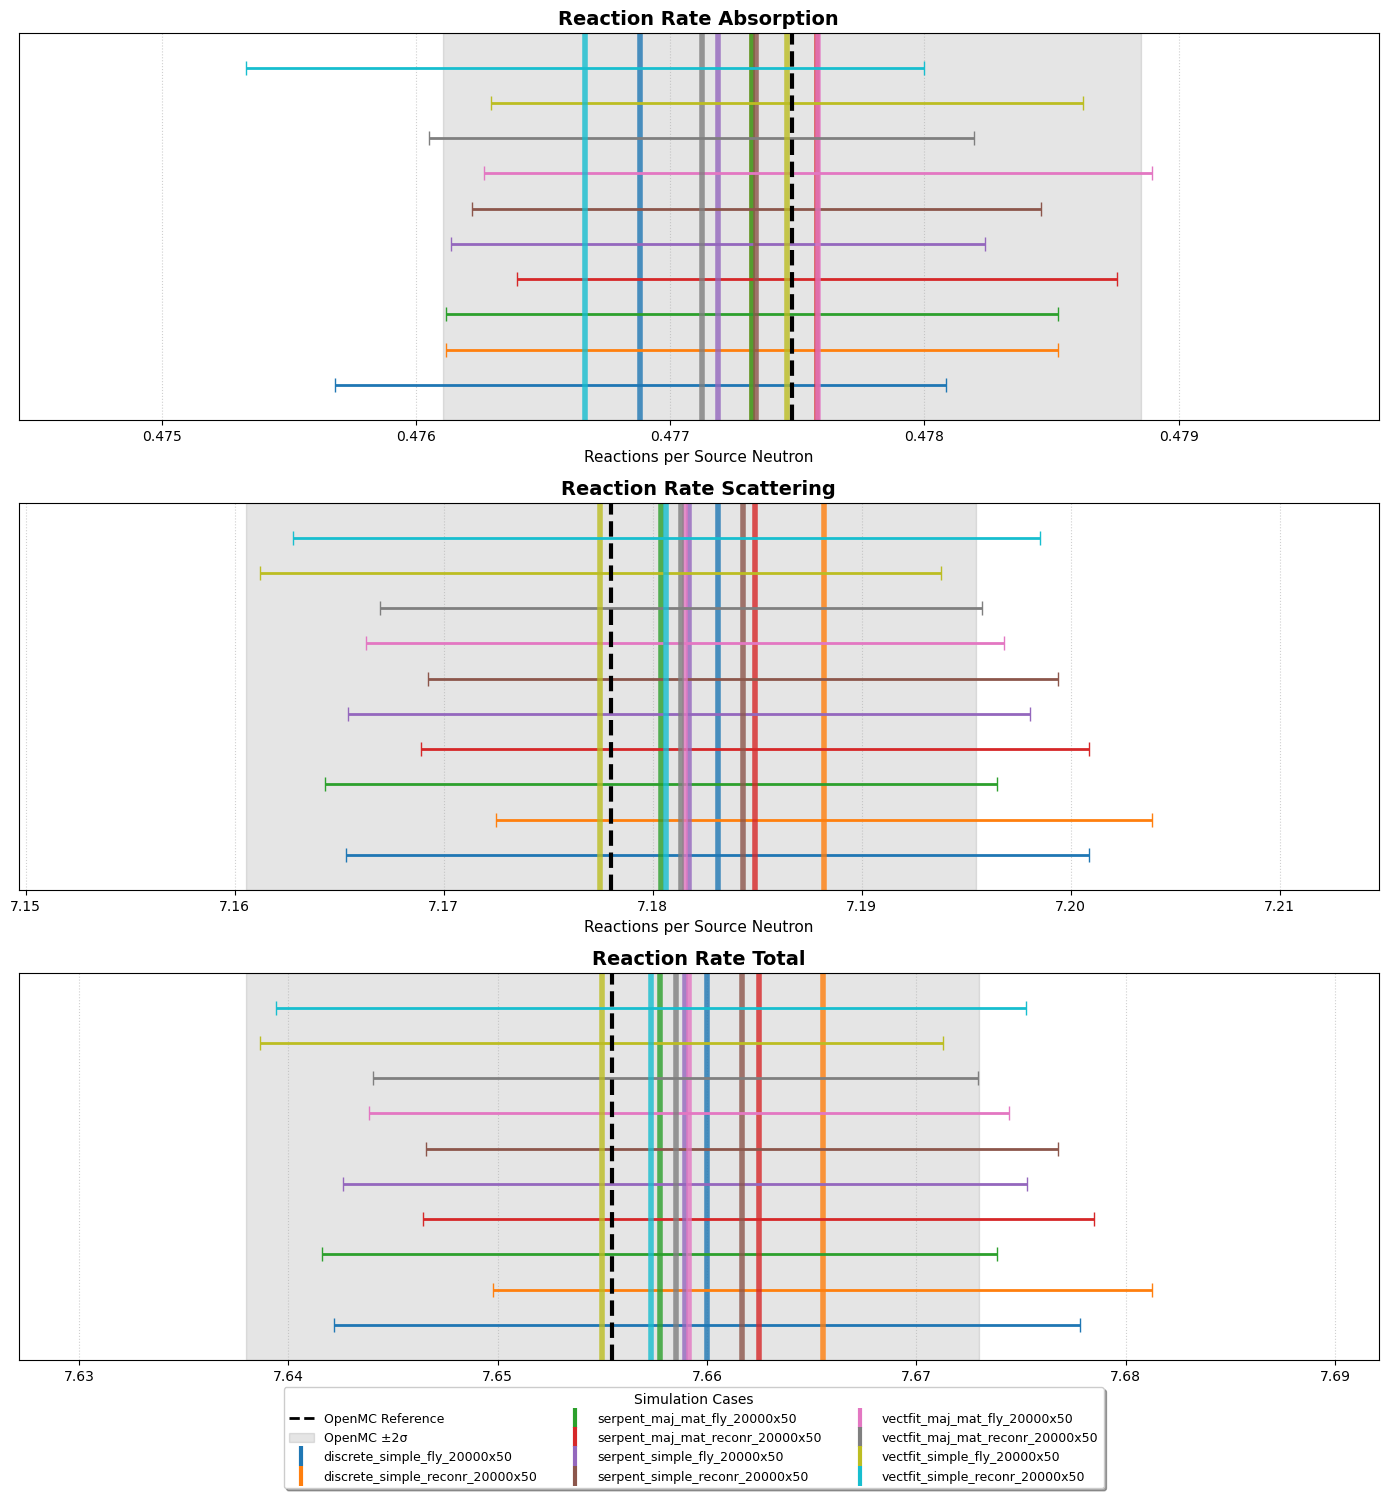

In [16]:
# Re-use valid_cases from Section 3

sim_cases  = sorted([c for c in valid_cases if c != 'openmc_results'])
all_cases  = sim_cases + (['openmc_results'] if 'openmc_results' in valid_cases else [])

METRICS    = ['Absorption', 'Scattering', 'Total']
global_data = {m: pd.DataFrame(index=all_cases, columns=['Mean', 'Std'], dtype=float)
               for m in METRICS}

for case, df in valid_cases.items():
    abs_mask  = df.index.str.startswith('absorption')
    scat_mask = df.index.str.startswith('scatter')

    m_abs  = df[abs_mask]['mean'].sum()
    s_abs  = np.sqrt((df[abs_mask]['std'] ** 2).sum())
    m_scat = df[scat_mask]['mean'].sum()
    s_scat = np.sqrt((df[scat_mask]['std'] ** 2).sum())

    global_data['Absorption'].loc[case]        = [m_abs,  s_abs]
    global_data['Scattering'].loc[case]        = [m_scat, s_scat]
    global_data['Total'].loc[case] = [
        m_abs + m_scat,
        np.sqrt(s_abs**2 + s_scat**2),
    ]

# --- Summary table ---
print(f'{"CASE NAME":<35} | {"ABSORPTION":<12} | {"SCATTERING":<12} | {"TOTAL RX":<12}')
print('-' * 85)
for case in all_cases:
    a = global_data['Absorption'].loc[case, 'Mean']
    s = global_data['Scattering'].loc[case, 'Mean']
    r = global_data['Total'].loc[case, 'Mean']
    print(f'{case:<35} | {a:.5f}      | {s:.5f}      | {r:.5f}')

# --- Visualisation ---
n_sims    = len(sim_cases)
color_map = {c: plt.cm.tab20(i / n_sims) for i, c in enumerate(sim_cases)}

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, metric in zip(axes, METRICS):
    res_df      = global_data[metric]
    vals_for_lim = []

    for i, case in enumerate(sim_cases):
        mean = res_df.loc[case, 'Mean']
        err  = 2 * res_df.loc[case, 'Std']
        y    = (i + 1) / (n_sims + 1)
        ax.axvline(mean, color=color_map[case], linewidth=4, alpha=0.8)
        ax.errorbar(mean, y, xerr=err, color=color_map[case], fmt='none', capsize=5, elinewidth=2)
        vals_for_lim += [mean - err, mean + err]

    if 'openmc_results' in res_df.index:
        ref_mean = res_df.loc['openmc_results', 'Mean']
        ref_err  = 2 * res_df.loc['openmc_results', 'Std']
        ax.axvline(ref_mean, color='black', linestyle='--', linewidth=3)
        ax.axvspan(ref_mean - ref_err, ref_mean + ref_err, color='black', alpha=0.1)
        vals_for_lim += [ref_mean - ref_err, ref_mean + ref_err]

    if vals_for_lim:
        lo, hi = min(vals_for_lim), max(vals_for_lim)
        pad    = (hi - lo) * 0.25 if hi != lo else 0.05 * abs(lo)
        ax.set_xlim(lo - pad, hi + pad)

    ax.set_title(f'Reaction Rate {metric}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Reactions per Source Neutron', fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.grid(True, axis='x', linestyle=':', alpha=0.6)

# Shared legend
legend_handles = [
    mlines.Line2D([], [], color='black', linestyle='--', linewidth=2, label='OpenMC Reference'),
    plt.Rectangle((0, 0), 1, 1, color='black', alpha=0.1, label='OpenMC ±2σ'),
] + [
    mlines.Line2D([], [], color=color_map[c], marker='|', markersize=15,
                  linestyle='None', markeredgewidth=3, label=c)
    for c in sim_cases
]
fig.legend(
    handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
    ncol=3, fontsize=9, frameon=True, shadow=True, title='Simulation Cases'
)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()